# Baseline Traditional Models

Train Linear Regression, Ridge Regression, and SVR on the pre-split, pre-scaled dataset (`data/final/`). Hyperparameter tuning via GridSearchCV with K-Fold cross-validation. Evaluation metrics: RMSE, MAE, R², Adjusted R².

## Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_SEED = 42
FINAL_DIR = os.path.join("..", "data", "final")
MODELS_DIR = os.path.join("..", "models")
REPORTS_DIR = os.path.join("..", "reports")

os.makedirs(MODELS_DIR, exist_ok=True)

In [2]:
X_train = pd.read_csv(os.path.join(FINAL_DIR, "X_train_scaled.csv"))
X_test  = pd.read_csv(os.path.join(FINAL_DIR, "X_test_scaled.csv"))
y_train = pd.read_csv(os.path.join(FINAL_DIR, "y_train.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(FINAL_DIR, "y_test.csv")).squeeze()

n_features = X_train.shape[1]

print(f"Training set: {X_train.shape[0]} samples, {n_features} features")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nFeatures: {list(X_train.columns)}")
X_train.head()

Training set: 2231 samples, 11 features
Test set:     558 samples

Features: ['Weed28D_thiobencarb', 'Nursery area (Cents)', 'Hectares ', 'LP_Mainfield(in Tonnes)', 'LP_nurseryarea(in Tonnes)', 'Seedrate(in Kg)', 'Pest_60Day(in ml)', 'Urea_40Days', 'Micronutrients_70Days', 'Potassh_50Days', 'DAP_20days']


,Weed28D_thiobencarb,Nursery area (Cents),Hectares,LP_Mainfield(in Tonnes),LP_nurseryarea(in Tonnes),Seedrate(in Kg),Pest_60Day(in ml),Urea_40Days,Micronutrients_70Days,Potassh_50Days,DAP_20days
0,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189
1,0.196546,0.196546,0.196546,0.196546,0.196546,0.196546,0.196546,0.196546,0.196546,0.196546,0.196546
2,-0.499097,-0.499097,-0.499097,-0.499097,-0.499097,-0.499097,-0.499097,-0.499097,-0.499097,-0.499097,-0.499097
3,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832
4,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189,0.892189


## K-Fold Cross-Validation & Evaluation Helper

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

results = []


def adjusted_r2(r2, n, p):
    """Adjusted R² = 1 - (1 - R²) * (n - 1) / (n - p - 1)"""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv):
    """Run K-fold CV on training data, then evaluate on the held-out test set."""
    p = X_tr.shape[1]

    scoring = {
        "neg_rmse": "neg_root_mean_squared_error",
        "neg_mae": "neg_mean_absolute_error",
        "r2": "r2",
    }
    cv_scores = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring)

    cv_rmse = -cv_scores["test_neg_rmse"].mean()
    cv_mae  = -cv_scores["test_neg_mae"].mean()
    cv_r2   =  cv_scores["test_r2"].mean()
    n_cv    =  len(y_tr) * (1 - 1 / cv.n_splits)  # avg fold train size
    cv_adj_r2 = adjusted_r2(cv_r2, n_cv, p)

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    test_rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    test_mae    = mean_absolute_error(y_te, y_pred)
    test_r2     = r2_score(y_te, y_pred)
    test_adj_r2 = adjusted_r2(test_r2, len(y_te), p)

    row = {
        "Model": name,
        "CV RMSE": cv_rmse, "CV MAE": cv_mae,
        "CV R²": cv_r2, "CV Adj. R²": cv_adj_r2,
        "Test RMSE": test_rmse, "Test MAE": test_mae,
        "Test R²": test_r2, "Test Adj. R²": test_adj_r2,
    }
    results.append(row)

    print(f"--- {name} ---")
    print(f"  CV   | RMSE: {cv_rmse:.2f}  MAE: {cv_mae:.2f}  R²: {cv_r2:.4f}  Adj. R²: {cv_adj_r2:.4f}")
    print(f"  Test | RMSE: {test_rmse:.2f}  MAE: {test_mae:.2f}  R²: {test_r2:.4f}  Adj. R²: {test_adj_r2:.4f}\n")

    return model

## Model 1: Linear Regression

In [4]:
lr_model = evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, y_train, X_test, y_test, kf
)

--- Linear Regression ---
  CV   | RMSE: 950.56  MAE: 717.38  R²: 0.9894  Adj. R²: 0.9893
  Test | RMSE: 948.75  MAE: 709.03  R²: 0.9889  Adj. R²: 0.9887



## Model 2: Ridge Regression (with Hyperparameter Tuning)

In [5]:
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    refit=True,
)
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best CV RMSE:     {-ridge_grid.best_score_:.2f}\n")

ridge_model = evaluate_model(
    "Ridge Regression",
    ridge_grid.best_estimator_,
    X_train, y_train, X_test, y_test, kf
)

Best Ridge alpha: 0.01
Best CV RMSE:     950.56

--- Ridge Regression ---
  CV   | RMSE: 950.56  MAE: 717.38  R²: 0.9894  Adj. R²: 0.9893
  Test | RMSE: 948.75  MAE: 709.03  R²: 0.9889  Adj. R²: 0.9887



## Model 3: Support Vector Regression (with Hyperparameter Tuning)

In [6]:
svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5],
    "kernel": ["rbf", "linear"],
}

svr_grid = GridSearchCV(
    SVR(),
    svr_params,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    refit=True,
    n_jobs=-1,
)
svr_grid.fit(X_train, y_train)

print(f"Best SVR params: {svr_grid.best_params_}")
print(f"Best CV RMSE:    {-svr_grid.best_score_:.2f}\n")

svr_model = evaluate_model(
    "SVR",
    svr_grid.best_estimator_,
    X_train, y_train, X_test, y_test, kf
)

Best SVR params: {'C': 10, 'epsilon': 0.01, 'kernel': 'linear'}
Best CV RMSE:    960.21



--- SVR ---
  CV   | RMSE: 960.21  MAE: 707.46  R²: 0.9892  Adj. R²: 0.9891
  Test | RMSE: 963.63  MAE: 705.54  R²: 0.9886  Adj. R²: 0.9883



## Results Comparison

In [7]:
results_df = pd.DataFrame(results).set_index("Model")
results_df.style.format("{:.4f}").highlight_min(
    subset=["CV RMSE", "CV MAE", "Test RMSE", "Test MAE"], color="lightgreen"
).highlight_max(
    subset=["CV R²", "CV Adj. R²", "Test R²", "Test Adj. R²"], color="lightgreen"
)

,CV RMSE,CV MAE,CV R²,CV Adj. R²,Test RMSE,Test MAE,Test R²,Test Adj. R²
Model,,,,,,,,
Linear Regression,950.5621,717.3783,0.9894,0.9893,948.7473,709.0288,0.9889,0.9887
Ridge Regression,950.5621,717.3785,0.9894,0.9893,948.7472,709.0289,0.9889,0.9887
SVR,960.2064,707.4605,0.9892,0.9891,963.6294,705.5447,0.9886,0.9883


## Visualizations

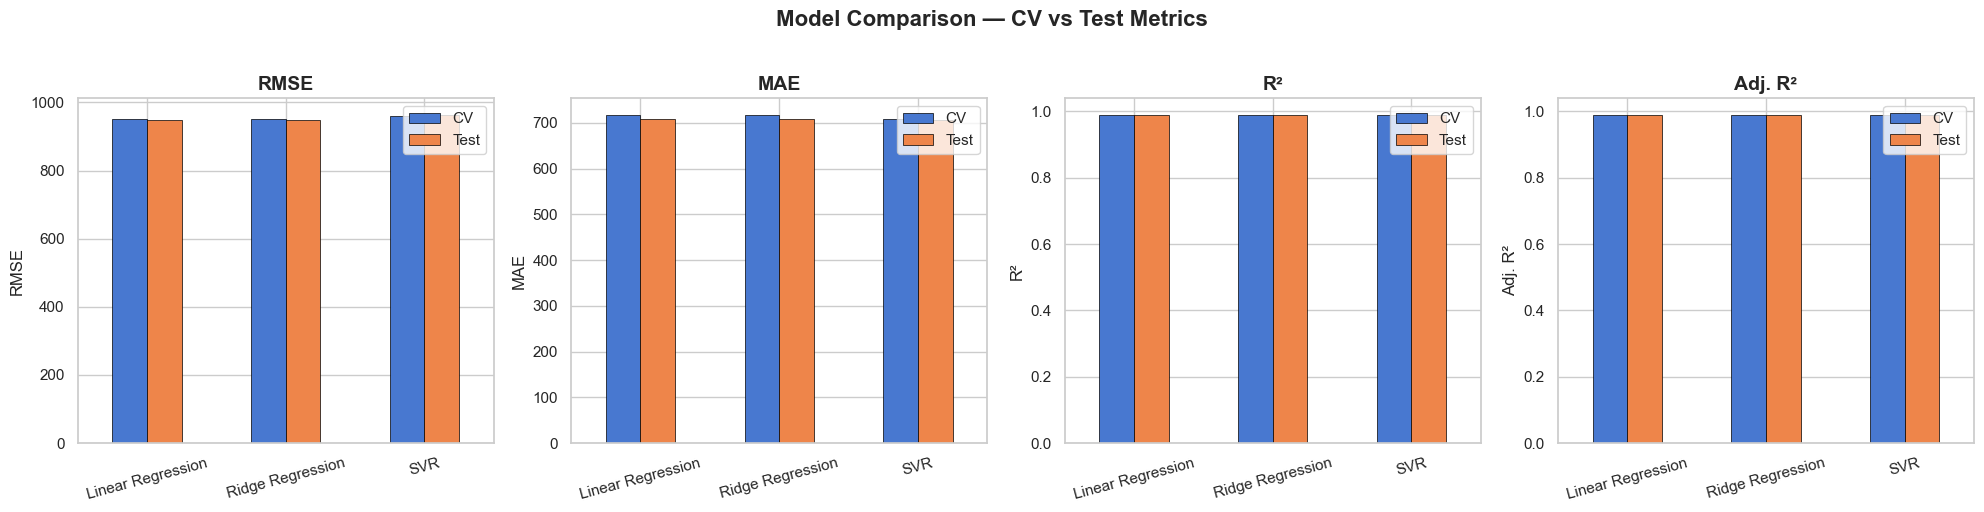

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = [("RMSE", False), ("MAE", False), ("R²", True), ("Adj. R²", True)]
for ax, (metric, _) in zip(axes, metrics):
    cv_col, test_col = f"CV {metric}", f"Test {metric}"
    plot_df = results_df[[cv_col, test_col]].rename(columns={cv_col: "CV", test_col: "Test"})
    plot_df.plot.bar(ax=ax, rot=15, edgecolor="black", linewidth=0.5)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.legend(frameon=True)

plt.suptitle("Model Comparison — CV vs Test Metrics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "baseline_metrics_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

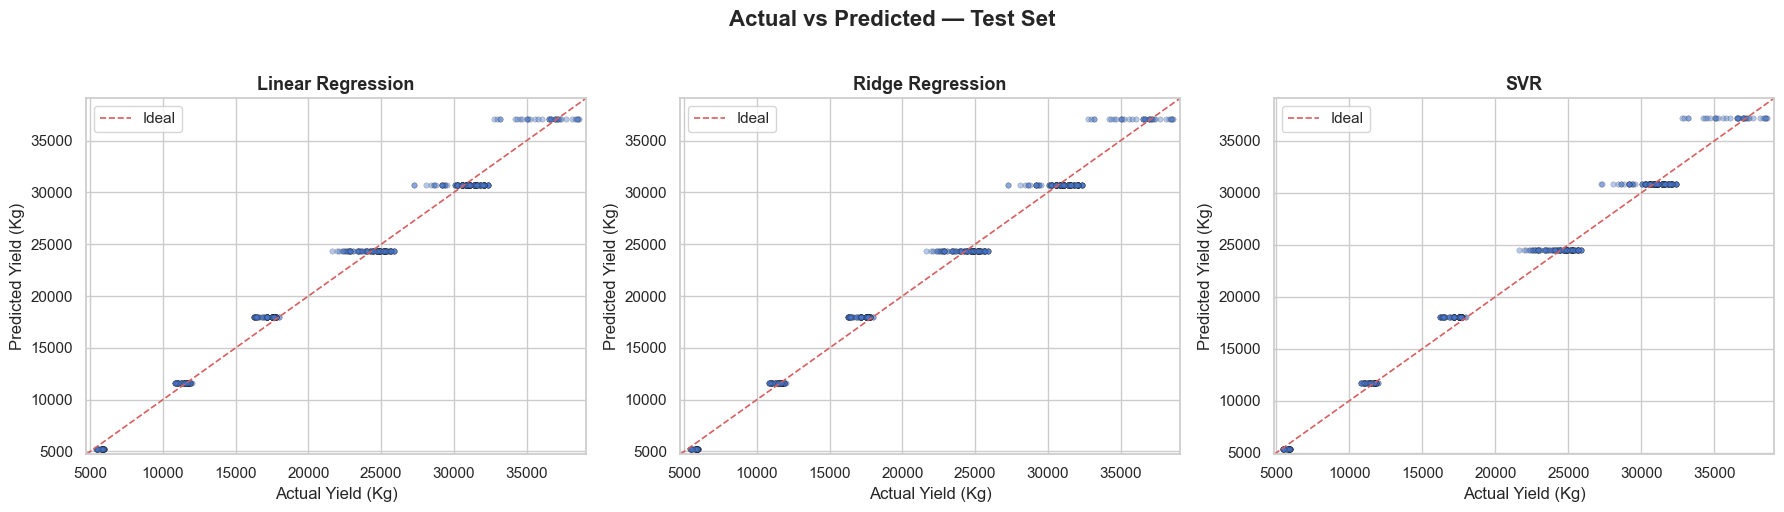

In [9]:
trained_models = {
    "Linear Regression": lr_model,
    "Ridge Regression": ridge_model,
    "SVR": svr_model,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    lims = [min(y_test.min(), y_pred.min()) - 500, max(y_test.max(), y_pred.max()) + 500]
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, edgecolors="k", linewidths=0.3)
    ax.plot(lims, lims, "r--", linewidth=1.2, label="Ideal")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual Yield (Kg)")
    ax.set_ylabel("Predicted Yield (Kg)")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left")

plt.suptitle("Actual vs Predicted — Test Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "baseline_actual_vs_predicted.png"), dpi=150, bbox_inches="tight")
plt.show()

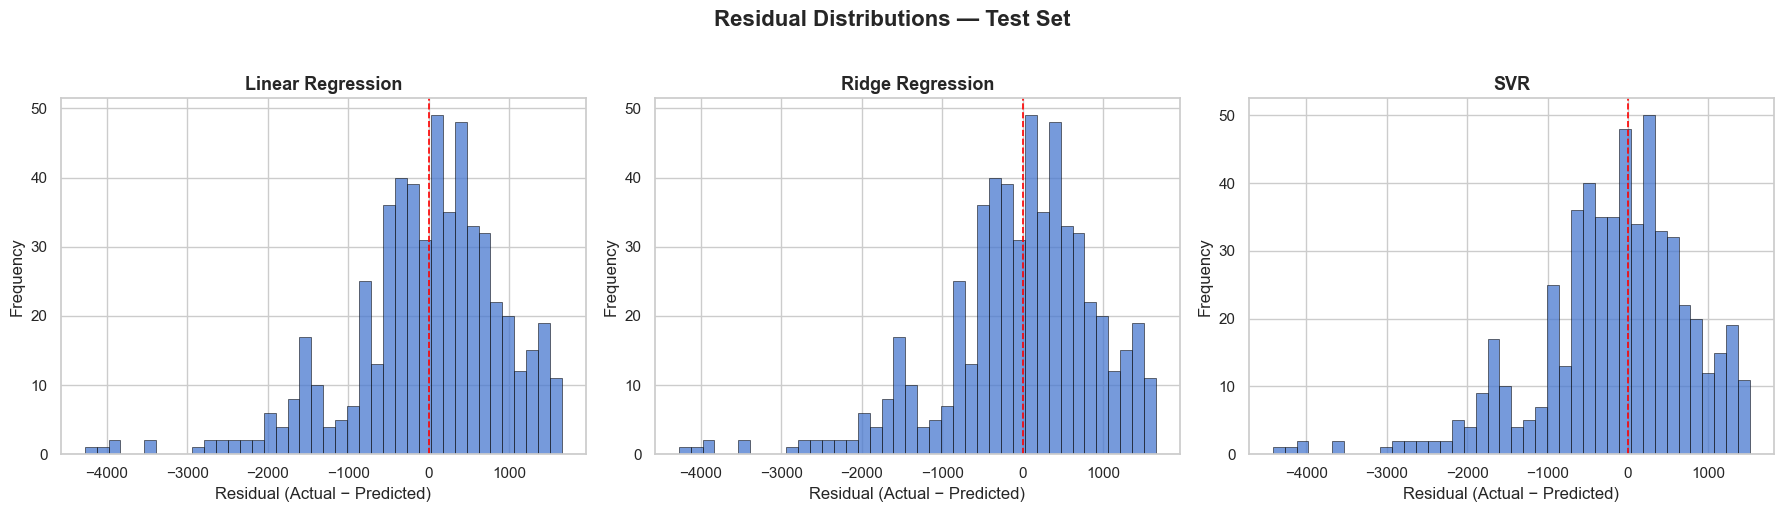

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    residuals = y_test - model.predict(X_test)
    ax.hist(residuals, bins=40, edgecolor="black", linewidth=0.5, alpha=0.75)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Frequency")
    ax.set_title(name, fontsize=13, fontweight="bold")

plt.suptitle("Residual Distributions — Test Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "baseline_residual_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save Models

In [11]:
models_to_save = {
    "linear_regression.pkl": lr_model,
    "ridge_regression.pkl": ridge_model,
    "svr.pkl": svr_model,
}

for filename, model in models_to_save.items():
    path = os.path.join(MODELS_DIR, filename)
    joblib.dump(model, path)
    print(f"Saved {filename} -> {path}")

Saved linear_regression.pkl -> ../models/linear_regression.pkl
Saved ridge_regression.pkl -> ../models/ridge_regression.pkl
Saved svr.pkl -> ../models/svr.pkl
